In [1]:
import sys, csv, os
sys.path.insert(0, "src")
import importlib
import numpy as np
import matplotlib.pyplot as plt
import mea_io, detection
importlib.reload(detection)
from scipy import signal as sps
import random

In [2]:
LABEL_CSV = "labeled_candidates.csv"
FEATURE_KEYS = ["amplitude_uv", "duration_s", "rise_time_s", "decay_time_s",
                "slope_uv_per_ms", "area_uv_ms", "half_width_s"]

file_name = "data/Armaan_Testing.h5"

def get_candidates(ch_idx, height_k=5.0, prominence_k=5.0,
                   min_distance_s=0.5, min_width_s=0.05):
    """Return (raw_signal, filtered_signal, refined_peak_indices) for a channel."""
    data, _ = mea_io.read_and_decimate(file_name, ch_idx)
    filtered = detection.bandpass_filter(data)
    noise_std = detection.mad_noise_std(filtered)
    candidates, _ = sps.find_peaks(
        -filtered,
        height=height_k * noise_std,
        prominence=prominence_k * noise_std,
        distance=max(1, int(min_distance_s * detection.FS)),
        width=max(1, int(min_width_s * detection.FS)),
    )
    refined = detection.refine_peaks(filtered, list(candidates))
    print(f"Channel {ch_idx}: {len(candidates)} from find_peaks → {len(refined)} after refine")
    return data, filtered, refined

In [10]:
random_numbers = random.sample(range(60), 20)

Channel 4: 42 from find_peaks → 42 after refine
Resuming — 867 candidates already labeled across all channels


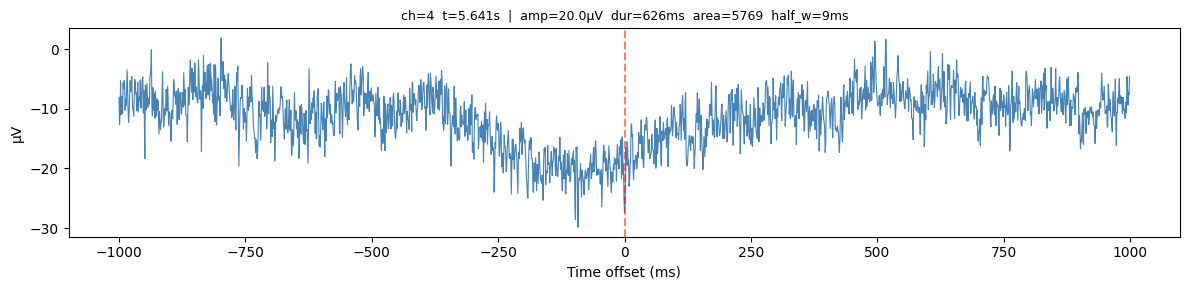

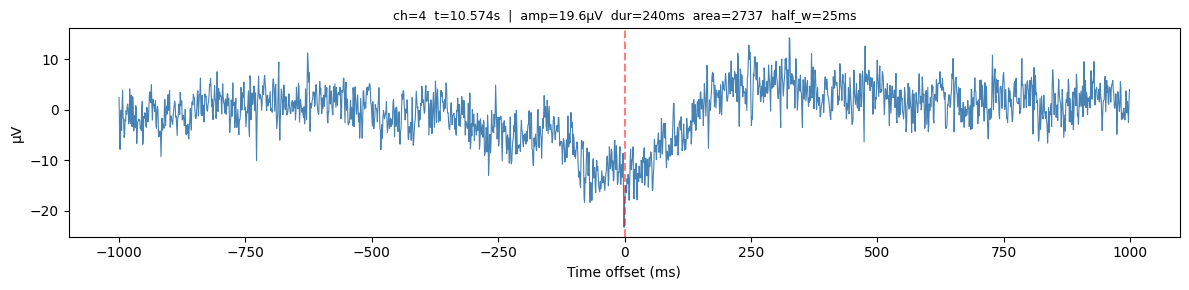

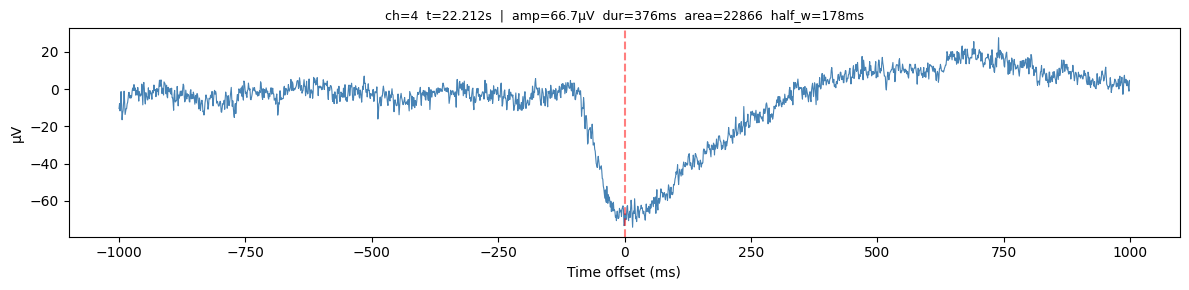

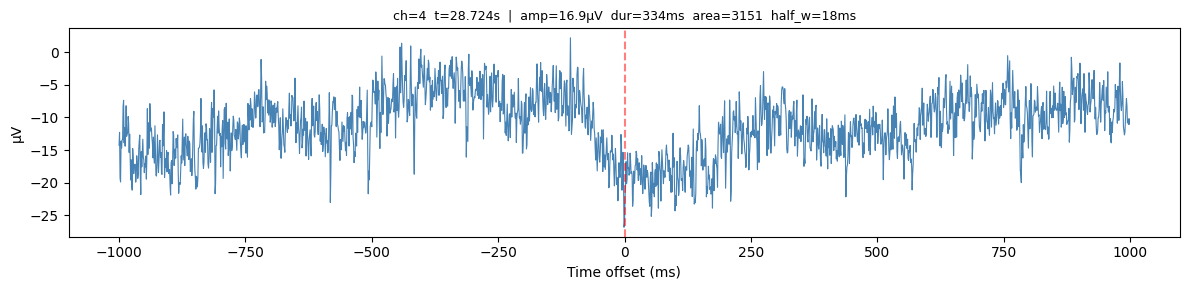

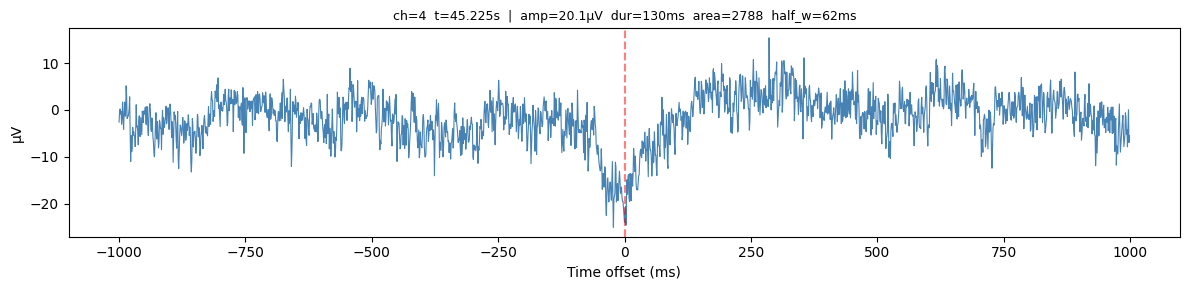

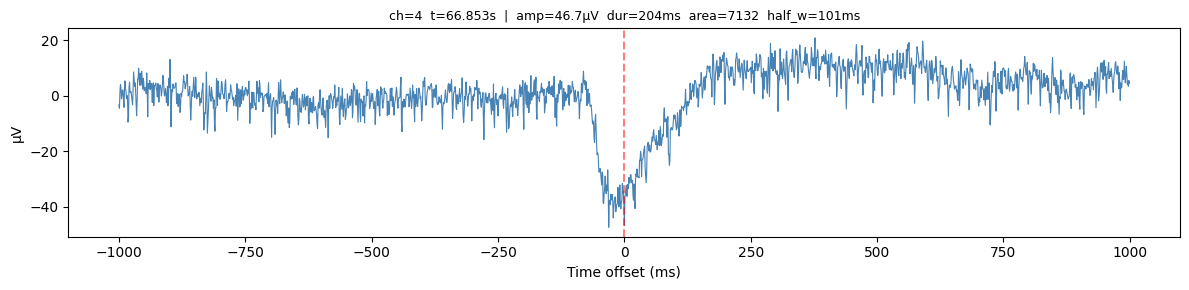

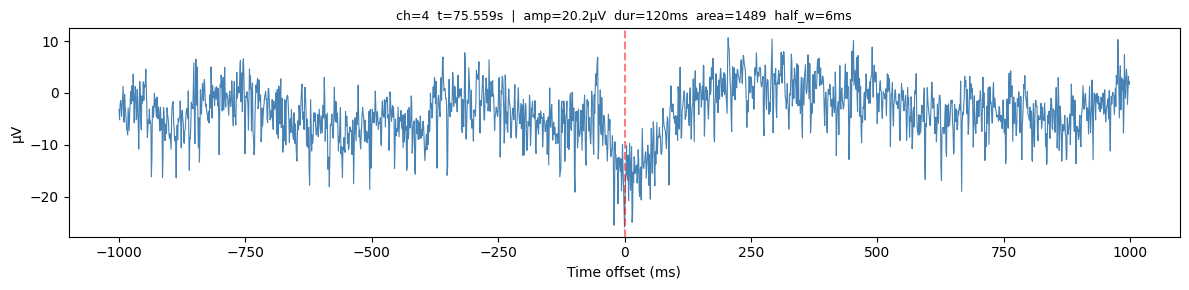

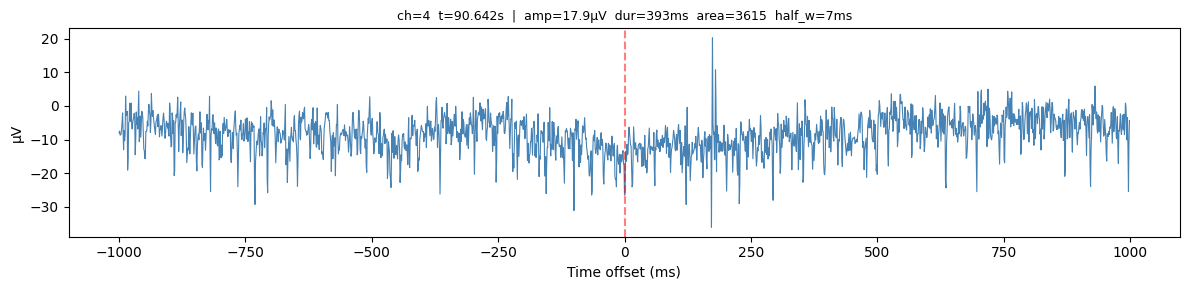

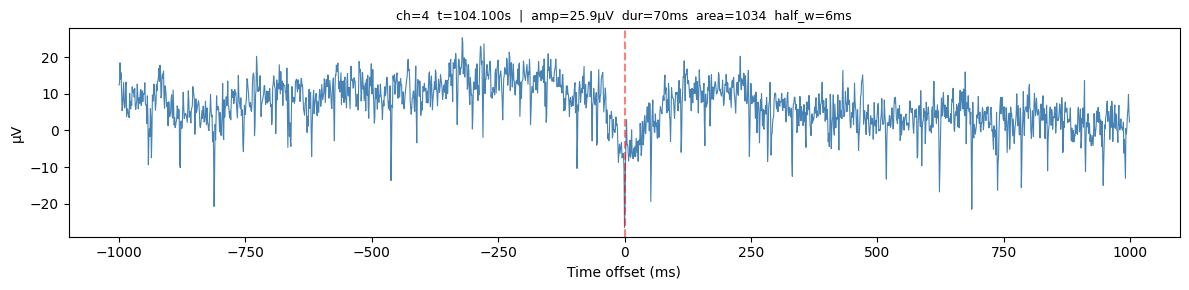

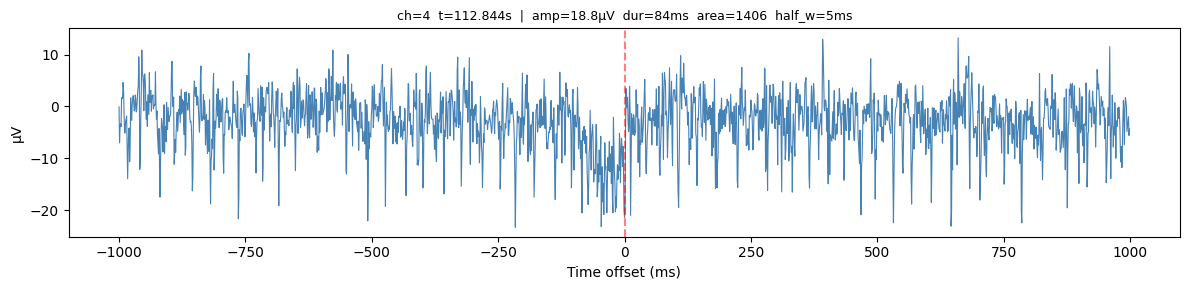

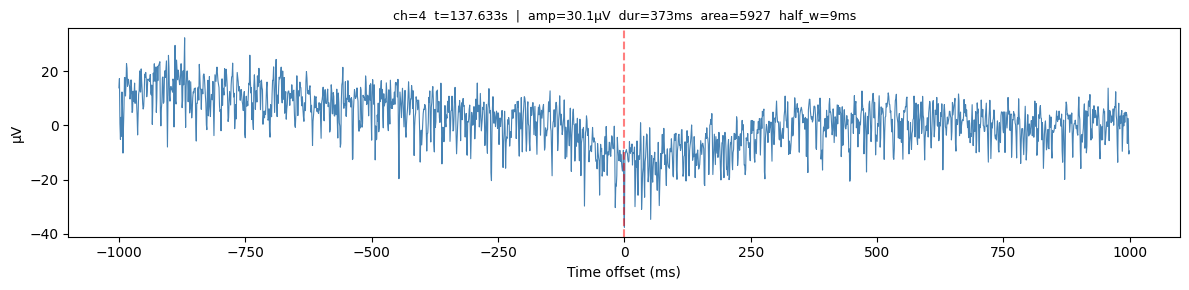

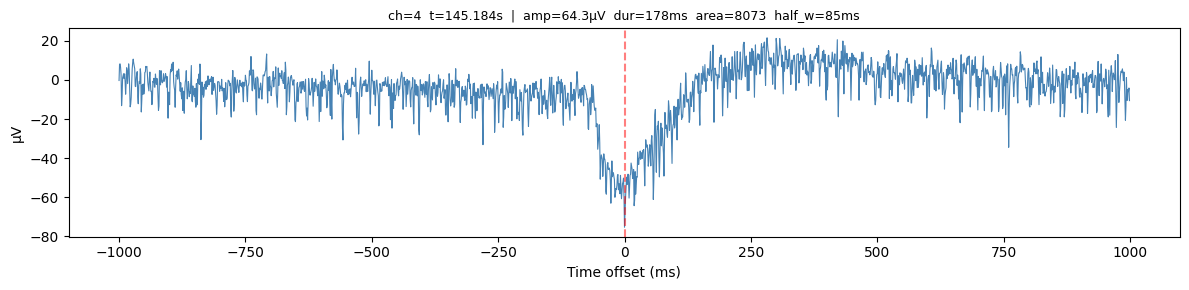

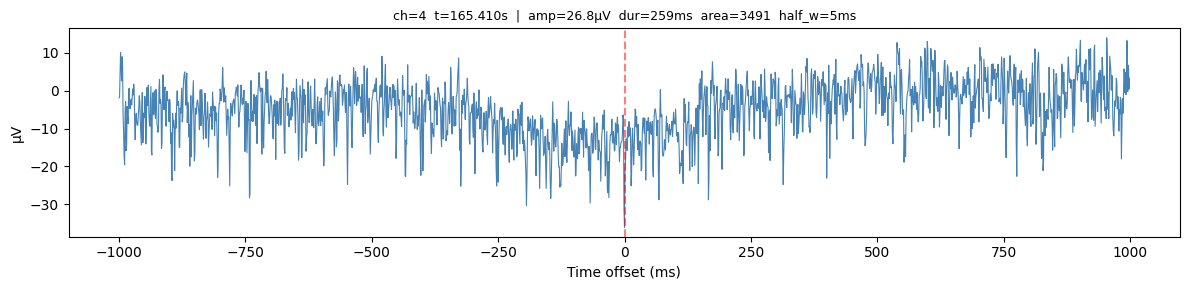

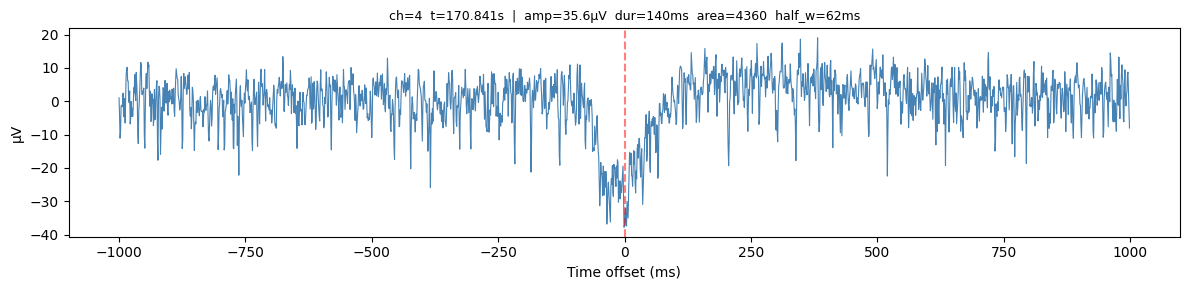

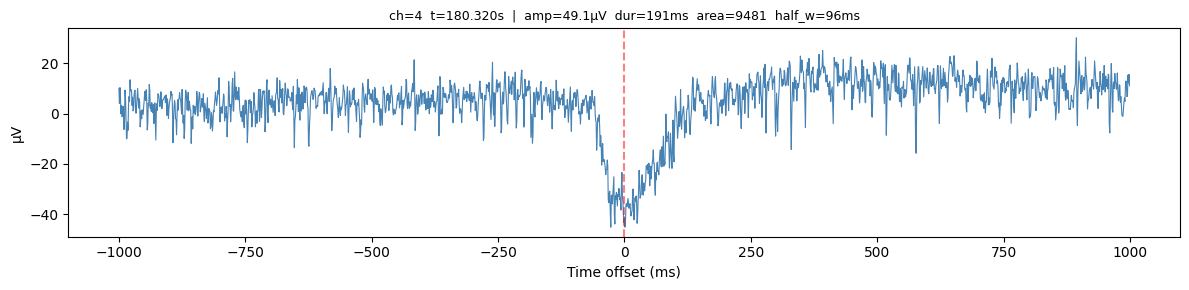

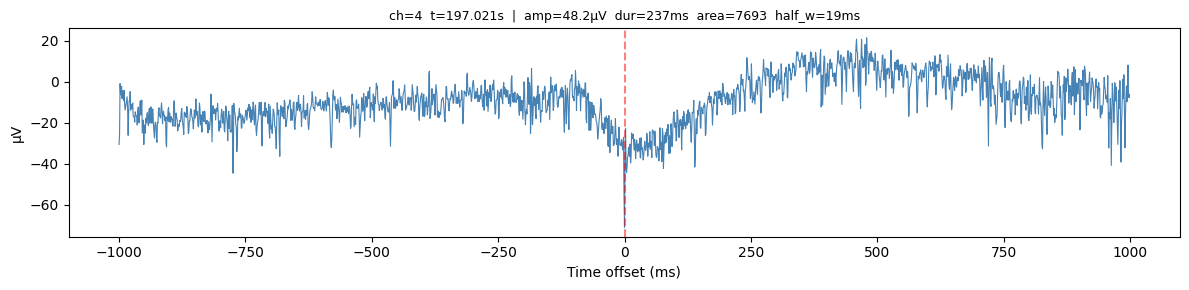

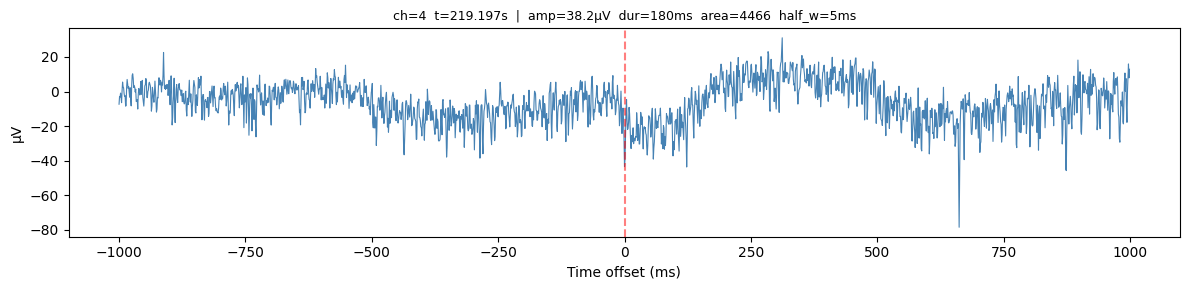

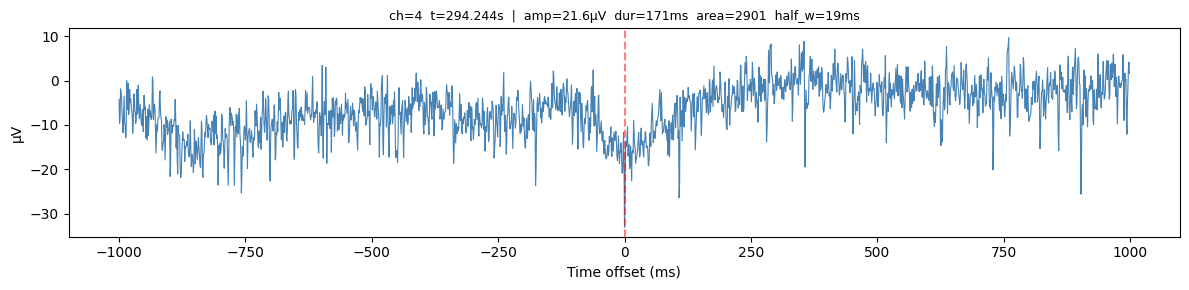

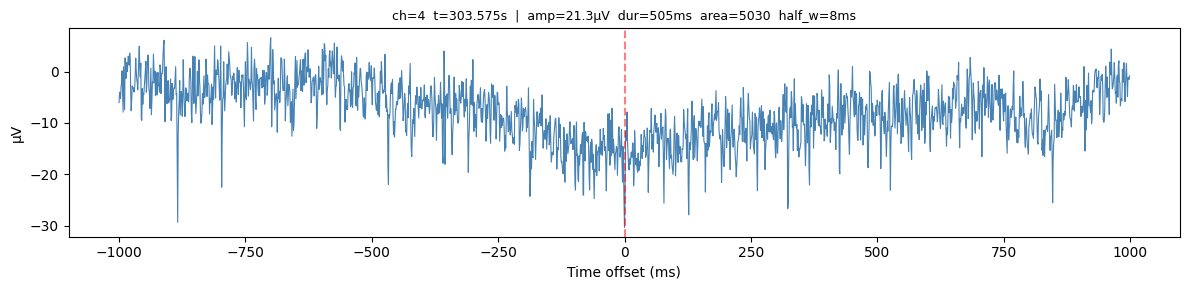

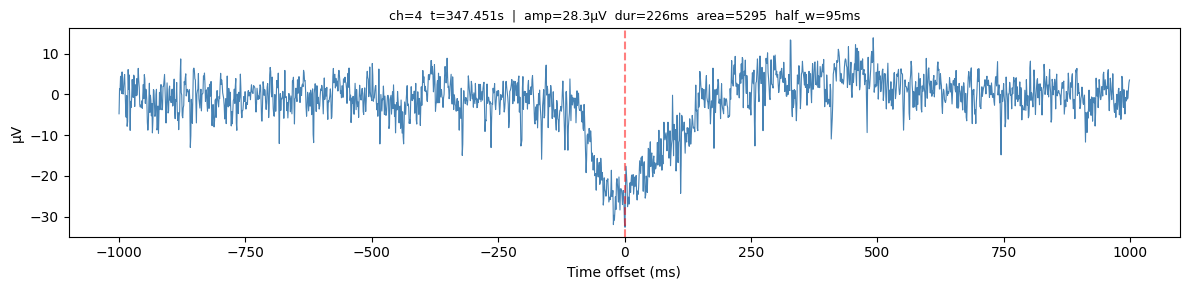

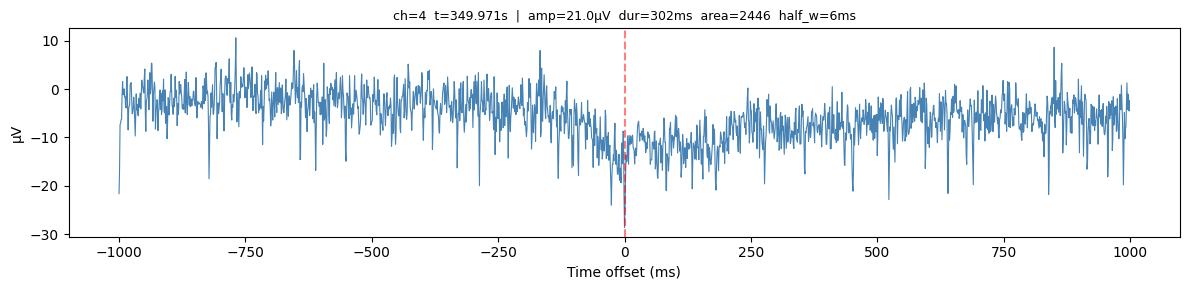

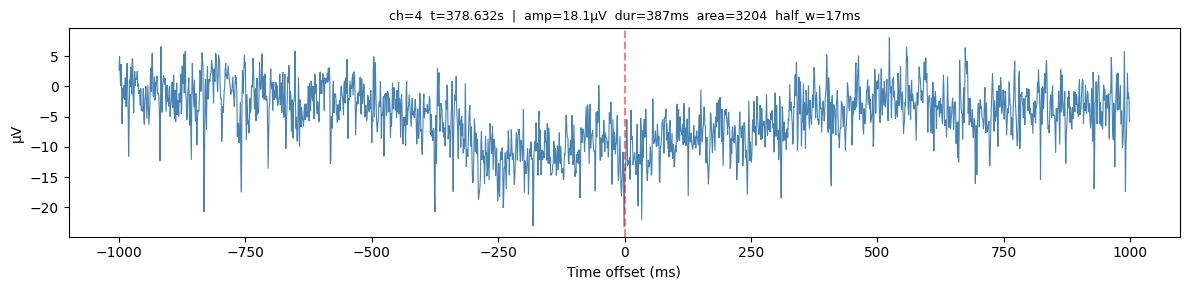

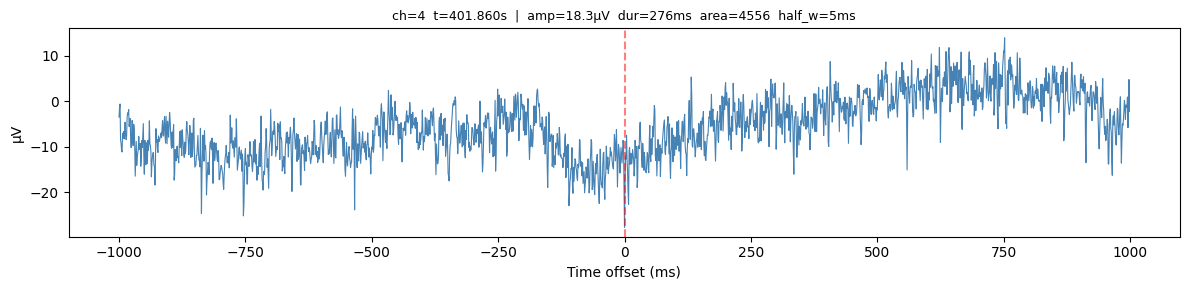

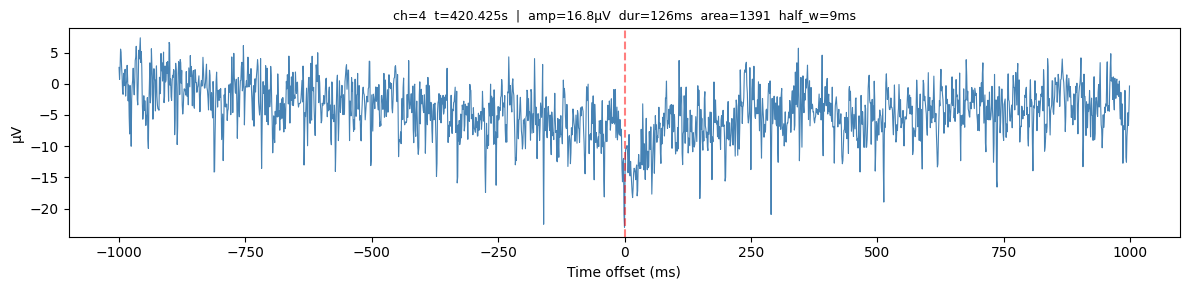

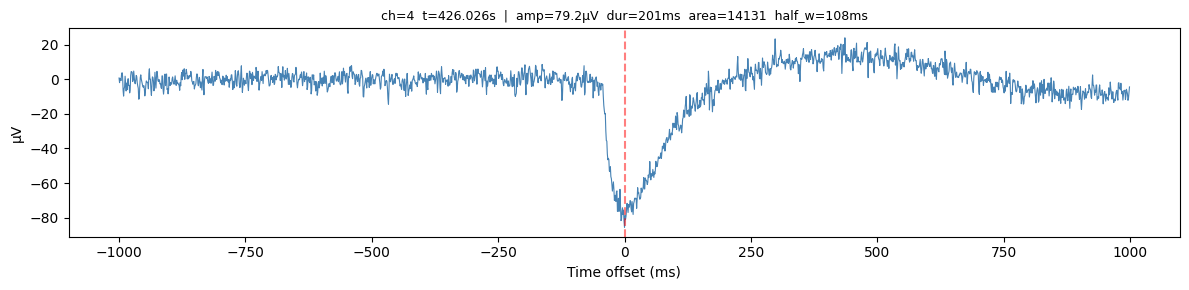

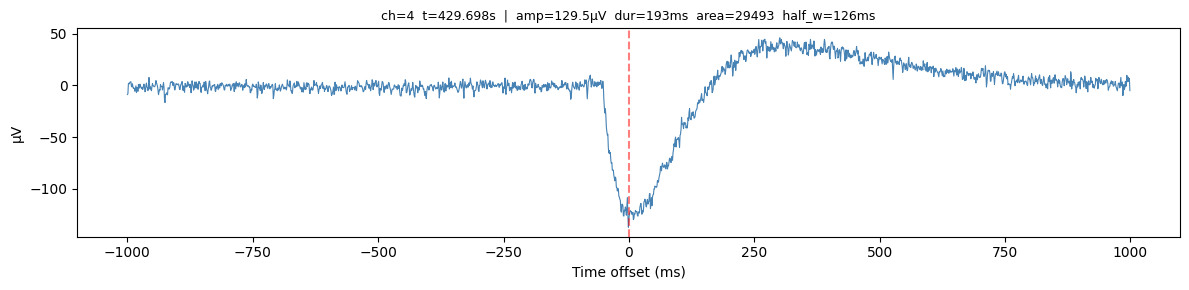

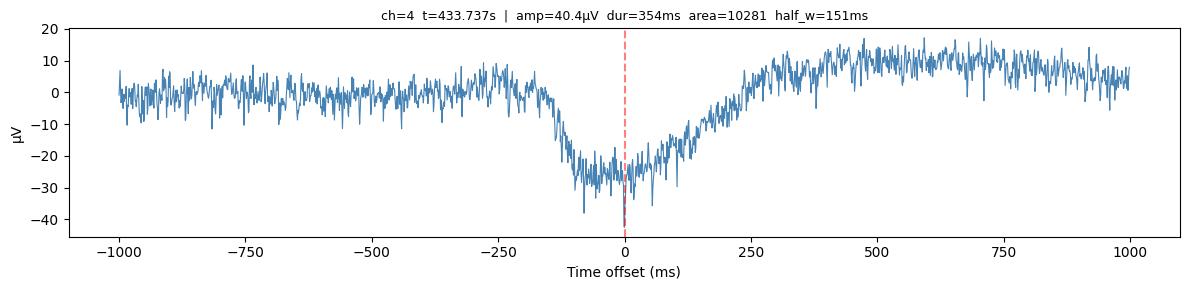

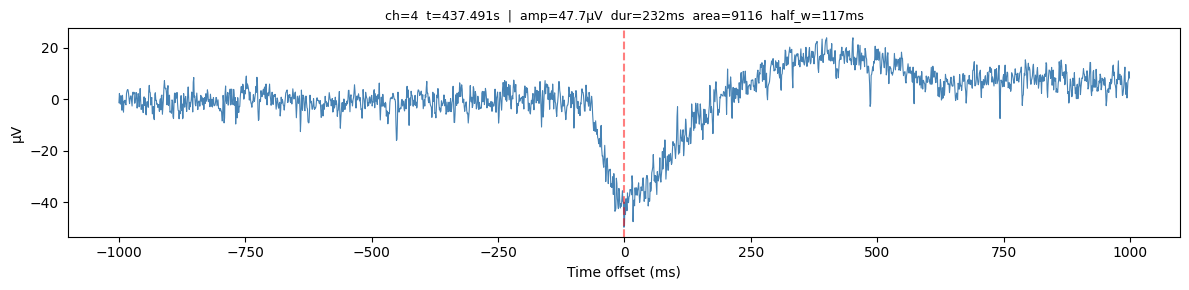

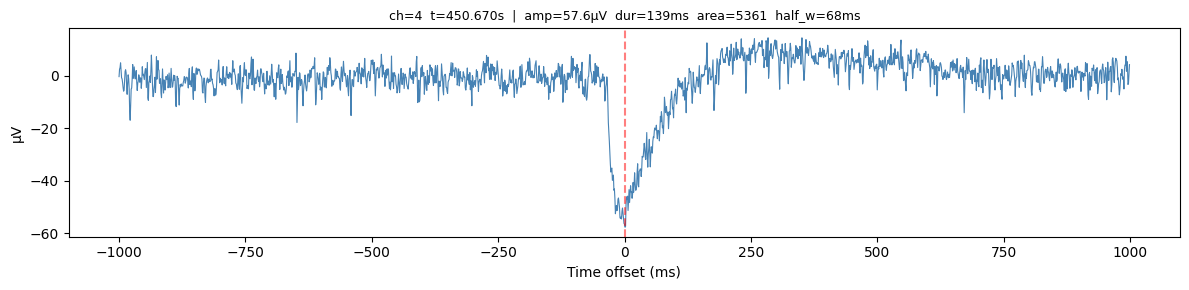

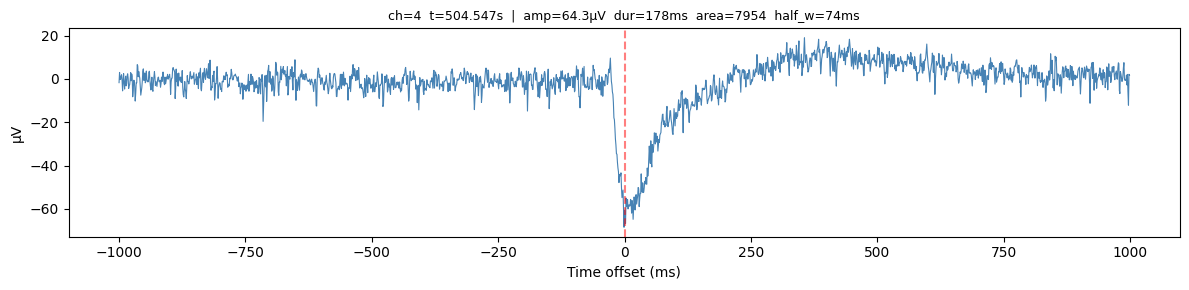

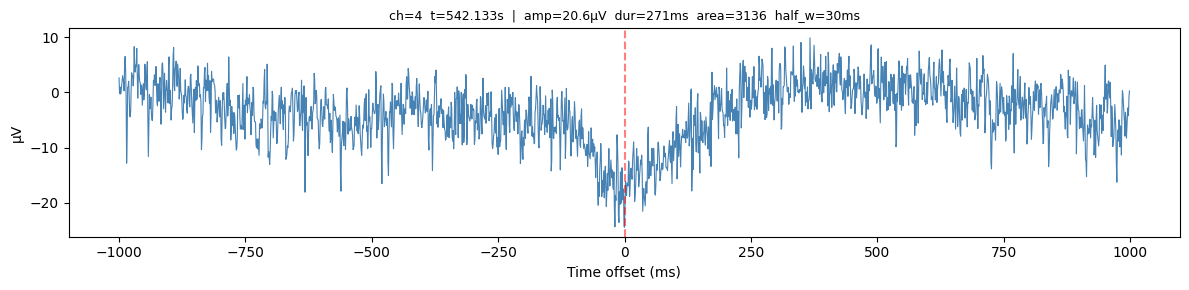

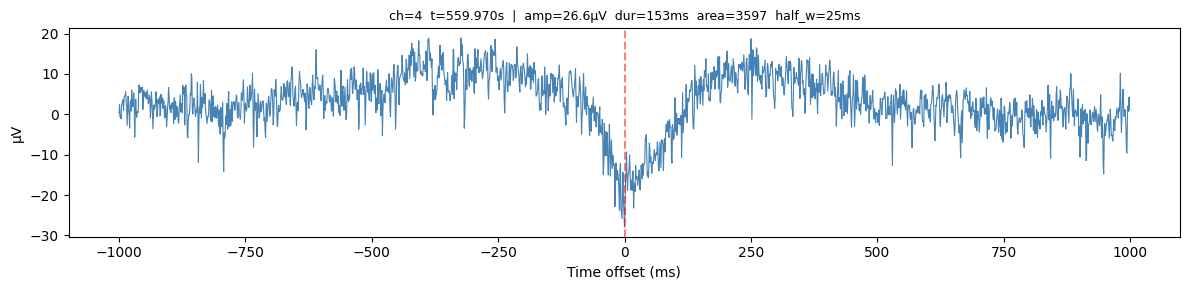

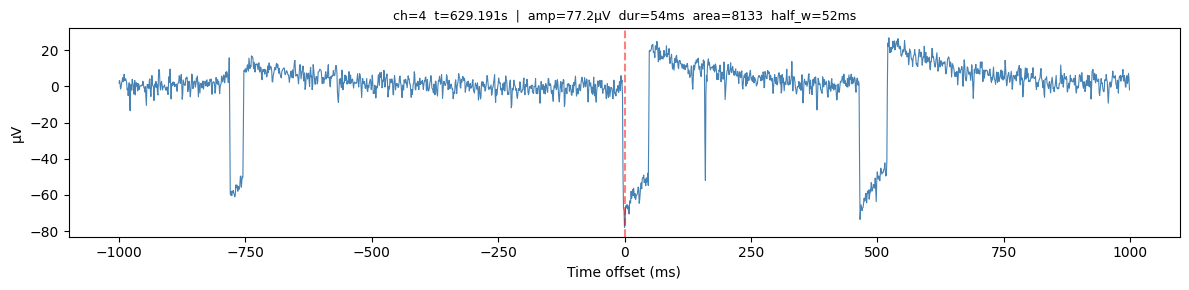

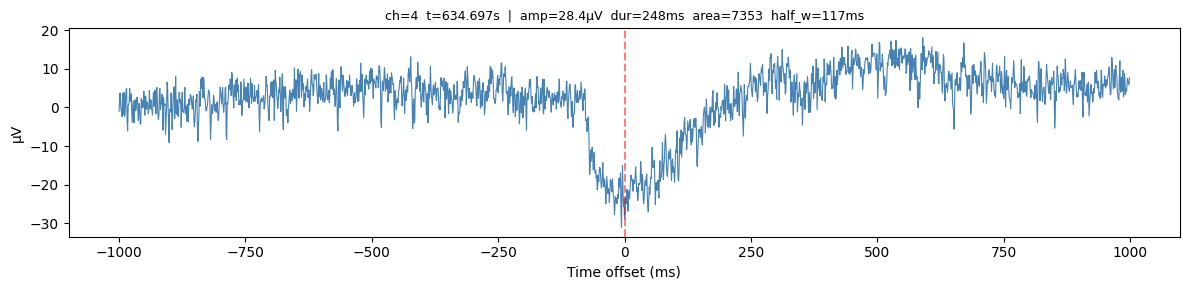

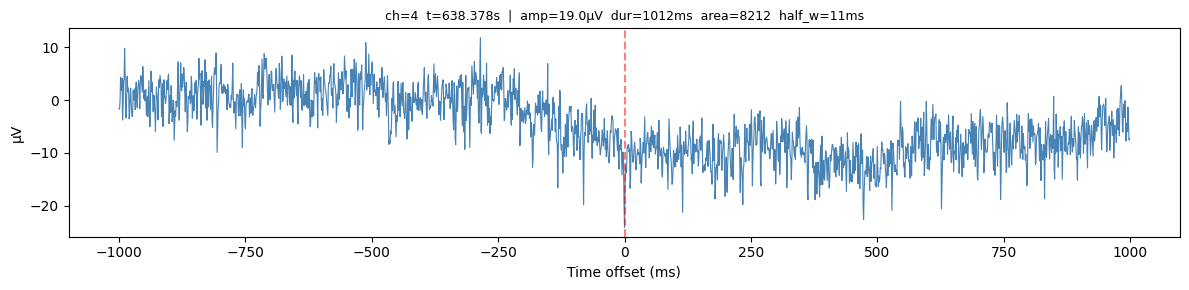

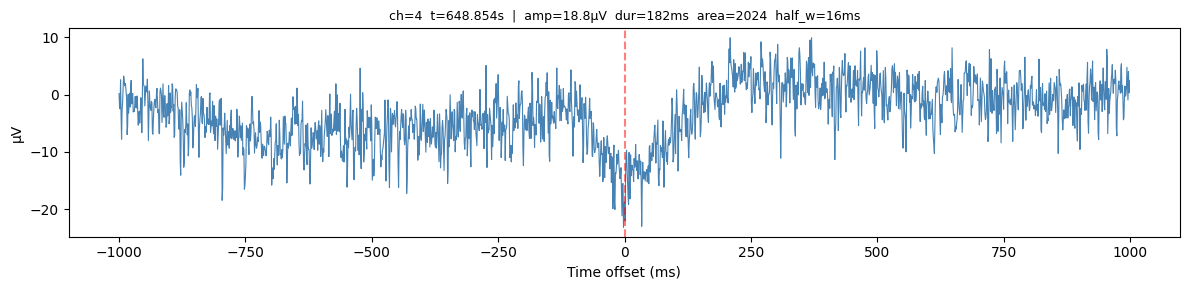

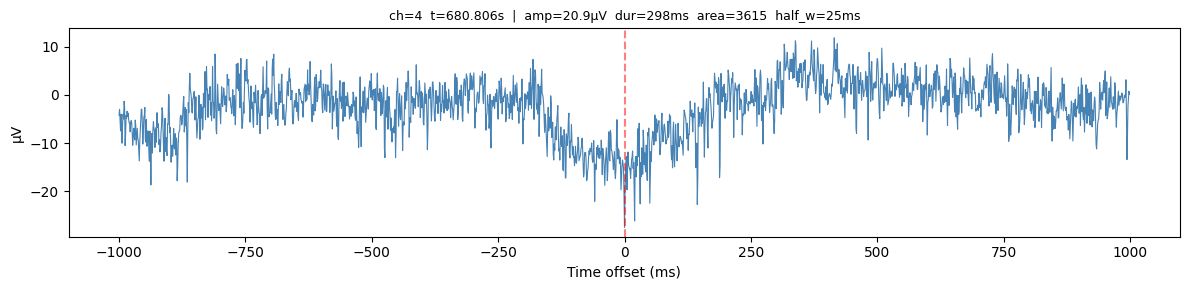

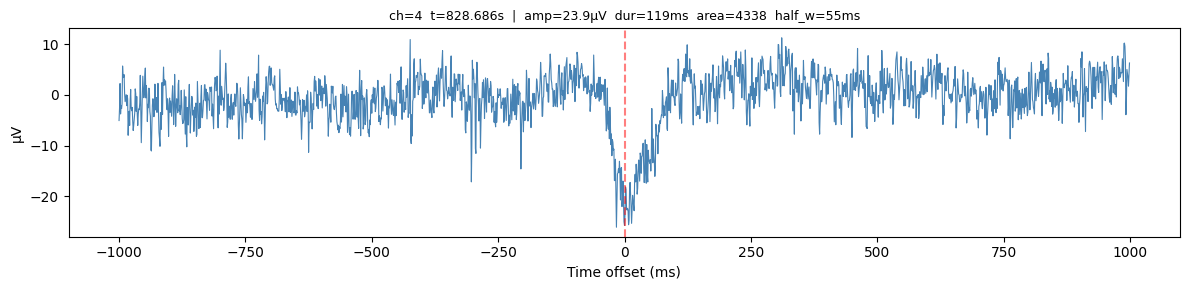

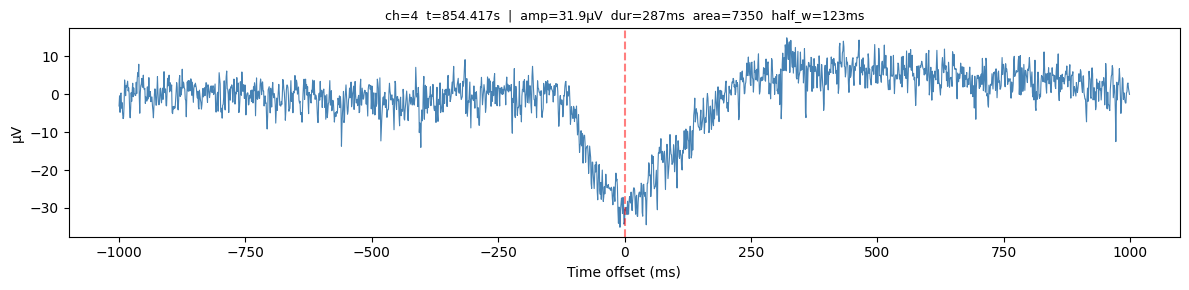

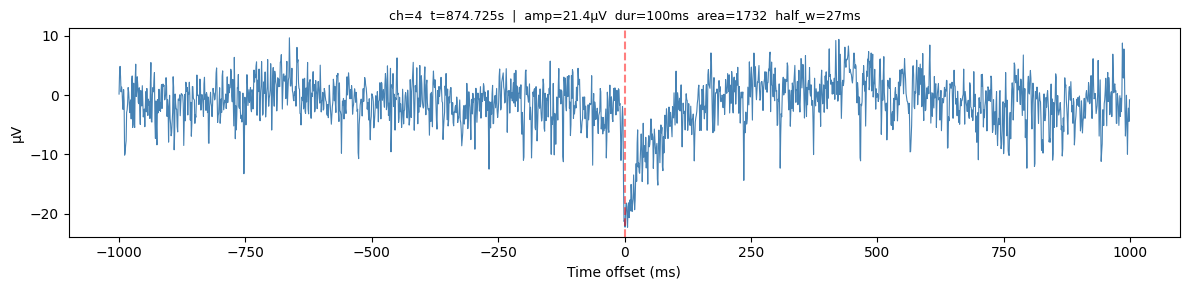

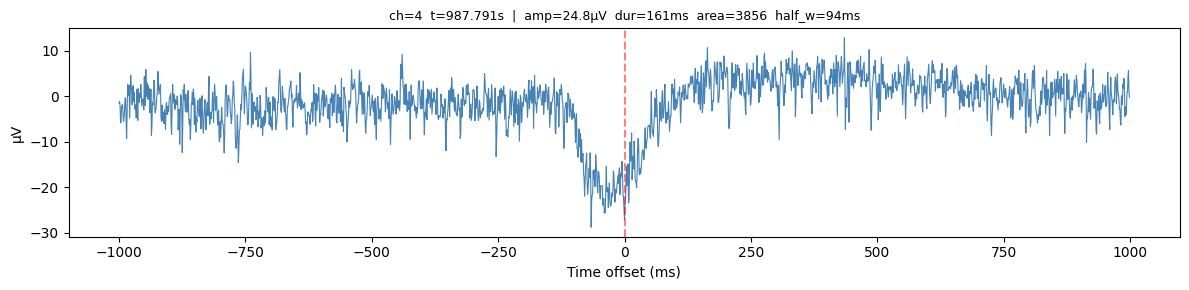

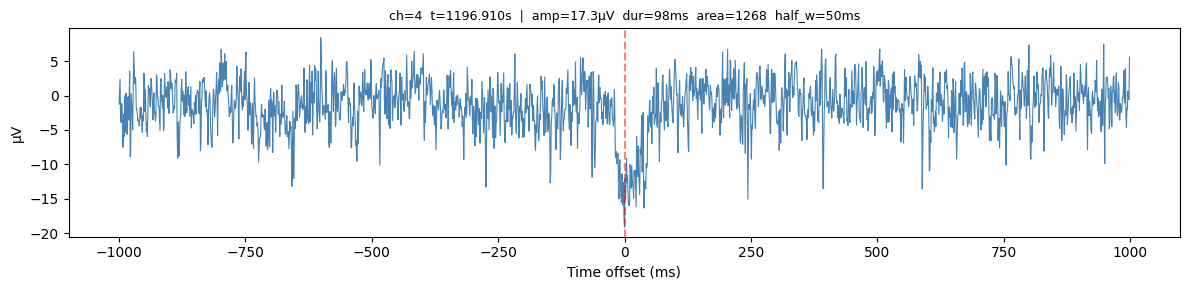

All candidates on channel 4 labeled (42 this run).


In [11]:
# ── LABELING LOOP ──────────────────────────────────────────────────────────────
# Change CH_IDX to label a different channel. Run this cell multiple times
# across different channels — all labels append to the same CSV.
# Controls: y = event,  n = not an event,  q = quit and save progress
# ──────────────────────────────────────────────────────────────────────────────
i = 19

chidx = random_numbers[i]

raw, filtered, refined = get_candidates(chidx)

# Load already-labeled entries so we can skip them on resume
existing = set()
if os.path.exists(LABEL_CSV):
    with open(LABEL_CSV, newline="") as f:
        for row in csv.DictReader(f):
            existing.add((int(row["ch_idx"]), int(row["sample_idx"])))
    print(f"Resuming — {len(existing)} candidates already labeled across all channels")

fieldnames = ["ch_idx", "sample_idx", "time_s", "label"] + FEATURE_KEYS
write_header = not os.path.exists(LABEL_CSV) or os.path.getsize(LABEL_CSV) == 0

half = detection.FS  # 1 second on each side
labeled_this_run = 0

with open(LABEL_CSV, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if write_header:
        writer.writeheader()

    for idx in refined:
        if (chidx, idx) in existing:
            continue

        feats = detection.compute_features(filtered, idx)
        start = max(0, idx - half)
        end   = min(len(raw), idx + half)
        t_ms  = (np.arange(start, end) - idx) / detection.FS * 1000

        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(t_ms, raw[start:end], linewidth=0.8, color="steelblue")
        ax.axvline(0, color="red", alpha=0.5, ls="--")
        ax.set_title(
            f"ch={chidx}  t={idx/detection.FS:.3f}s  |  "
            f"amp={feats['amplitude_uv']:.1f}µV  "
            f"dur={feats['duration_s']*1000:.0f}ms  "
            f"area={feats['area_uv_ms']:.0f}  "
            f"half_w={feats['half_width_s']*1000:.0f}ms",
            fontsize=9
        )
        ax.set_xlabel("Time offset (ms)")
        ax.set_ylabel("µV")
        plt.tight_layout()
        plt.show()

        answer = input("Label — y (event) / n (not event) / q (quit): ").strip().lower()
        plt.close()

        if answer == "q":
            print(f"Stopped. Labeled {labeled_this_run} this run. Re-run cell to continue.")
            break
        elif answer not in ("y", "n"):
            print(f"  Skipping unrecognised input '{answer}'")
            continue

        row = {
            "ch_idx": chidx, "sample_idx": idx,
            "time_s": round(idx / detection.FS, 4),
            "label": 1 if answer == "y" else 0,
        }
        row.update({k: round(feats[k], 6) for k in FEATURE_KEYS})
        writer.writerow(row)
        existing.add((chidx, idx))
        labeled_this_run += 1
    else:
        print(f"All candidates on channel {chidx} labeled ({labeled_this_run} this run).")

In [10]:
## **Not yet gng**

In [12]:
# ── MODEL TRAINING ─────────────────────────────────────────────────────────────
# Run after labeling at least 2–3 channels worth of candidates.
# Saves model to src/event_classifier.joblib — detection.py picks it up from there.
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

df = pd.read_csv(LABEL_CSV)
n_events    = df["label"].sum()
n_nonevents = (df["label"] == 0).sum()
print(f"Labeled samples: {len(df)}  |  events: {n_events}  |  non-events: {n_nonevents}")

if n_events < 5 or n_nonevents < 5:
    print("Need at least 5 of each class before training — label more candidates first.")
else:
    X_train = df[FEATURE_KEYS].values
    y_train = df["label"].values

    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")
    print(f"5-fold CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

    clf.fit(X_train, y_train)
    joblib.dump(clf, "src/event_classifier.joblib")
    print("Model saved → src/event_classifier.joblib")

    importances = sorted(zip(FEATURE_KEYS, clf.feature_importances_), key=lambda x: -x[1])
    print("\nFeature importances:")
    for feat, imp in importances:
        bar = "█" * int(imp * 40)
        print(f"  {feat:<20} {imp:.3f}  {bar}")

Labeled samples: 909  |  events: 445  |  non-events: 464
5-fold CV F1: 0.802 ± 0.034
Model saved → src/event_classifier.joblib

Feature importances:
  half_width_s         0.272  ██████████
  amplitude_uv         0.174  ██████
  duration_s           0.134  █████
  area_uv_ms           0.116  ████
  decay_time_s         0.109  ████
  rise_time_s          0.103  ████
  slope_uv_per_ms      0.092  ███
